In [2]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=ebe4005da52187fa526304957cebe640233f9cd683a9d9bdaae032bc4e8ec772
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [3]:
import os

# Create the directory for student images
if not os.path.exists('student_faces'):
    os.makedirs('student_faces')
    print("Folder 'student_faces' created.")
    print("Please upload student images into this folder on the left sidebar.")
    print("Ensure filenames are the student names (e.g., 'Amit.jpg').")
else:
    print("Folder 'student_faces' already exists.")

Folder 'student_faces' created.
Please upload student images into this folder on the left sidebar.
Ensure filenames are the student names (e.g., 'Amit.jpg').


In [5]:
import face_recognition
import cv2
import os
import numpy as np

known_face_encodings = []
known_face_names = []

image_folder = 'student_faces'

print("Processing known faces...")

# Loop through each file in the folder
for filename in os.listdir(image_folder):
    if filename.endswith(('.jpg', '.jpeg', '.png')):
        # Load image
        filepath = os.path.join(image_folder, filename)
        img = face_recognition.load_image_file(filepath)

        # Get encoding (assuming one face per image)
        try:
            encoding = face_recognition.face_encodings(img)[0]

            # Use filename without extension as the name
            name = os.path.splitext(filename)[0]

            known_face_encodings.append(encoding)
            known_face_names.append(name)
            print(f"Loaded: {name}")
        except IndexError:
            print(f"Warning: No face found in {filename}. Skipping.")

print(f"\nTotal known students: {len(known_face_names)}")

Processing known faces...
Loaded: sudipta2
Loaded: partha3
Loaded: samarpan
Loaded: partha2
Loaded: Sir
Loaded: para1
Loaded: parag3
Loaded: parag2
Loaded: mehul
Loaded: srija2
Loaded: darpan3
Loaded: suparna1
Loaded: srija3
Loaded: sudipta1
Loaded: suparna2
Loaded: subhadeep
Loaded: darpan2
Loaded: esha1
Loaded: darpan1
Loaded: partha1
Loaded: srija1

Total known students: 21


In [6]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Stop Attendance';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      // await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

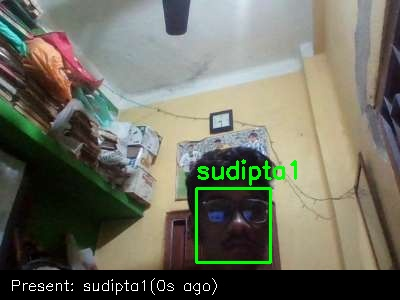

Time Remaining: 105s


<IPython.core.display.Javascript object>

Stopped by User.

--- FINAL CLASS LIST ---
['sudipta1']


In [7]:
import time
from IPython.display import display, Image, clear_output
import cv2
import numpy as np
from google.colab.output import eval_js
from base64 import b64decode

# --- CONFIGURATION ---
TIMEOUT_SECONDS = 30  # Student removed if not seen for 120s
TOTAL_RUNTIME = 120    # Runs for 4 minutes
# ---------------------

def get_video_frame_data():
    js = Javascript('''
      async function createStream() {
        if (!window.stream) {
            window.stream = await navigator.mediaDevices.getUserMedia({ video: true });
        }
        const video = document.createElement('video');
        video.style.display = 'none';
        video.srcObject = window.stream;
        await video.play();

        const canvas = document.createElement('canvas');
        canvas.width = 400;
        canvas.height = 300;
        canvas.getContext('2d').drawImage(video, 0, 0, canvas.width, canvas.height);

        return canvas.toDataURL('image/jpeg', 0.6);
      }
      createStream();
    ''')
    display(js)
    return eval_js('createStream()')

# Trackers
active_attendance = {} # { Name: Last_Seen_Timestamp }
start_time = time.time()

print("Starting Visual Attendance System...")

try:
    while (time.time() - start_time) < TOTAL_RUNTIME:
        current_time = time.time()

        # 1. Capture Frame
        data_url = get_video_frame_data()
        binary = b64decode(data_url.split(',')[1])
        img_array = np.frombuffer(binary, dtype=np.uint8)
        frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        # 2. Detect Faces
        # Convert to RGB for face_recognition library
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        face_locations = face_recognition.face_locations(rgb_frame)
        face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

        # 3. Identify Faces
        for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
            matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
            name = "Unknown"
            color = (0, 0, 255) # Red for unknown

            face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)
            if len(face_distances) > 0:
                best_match_index = np.argmin(face_distances)
                if matches[best_match_index]:
                    name = known_face_names[best_match_index]
                    color = (0, 255, 0) # Green for known

                    # Update Attendance Tracker
                    active_attendance[name] = current_time

            # Draw Box and Name
            cv2.rectangle(frame, (left, top), (right, bottom), color, 2)
            cv2.putText(frame, name, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        # 4. Check for Timeouts (The 120s Rule)
        students_to_remove = []
        status_text = "Present: "

        for student, last_seen in active_attendance.items():
            time_since_seen = current_time - last_seen

            if time_since_seen > TIMEOUT_SECONDS:
                students_to_remove.append(student)
            else:
                # Add to status text (Name: 5s ago)
                status_text += f"{student}({int(time_since_seen)}s ago) "

        # Remove timed-out students
        for student in students_to_remove:
            del active_attendance[student]

        # 5. Add Status Bar to Image
        cv2.rectangle(frame, (0, frame.shape[0]-30), (frame.shape[1], frame.shape[0]), (0,0,0), -1)
        cv2.putText(frame, status_text, (10, frame.shape[0]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # 6. Display the Image
        _, encoded_img = cv2.imencode('.jpg', frame)
        clear_output(wait=True) # Clears the previous frame to create animation effect
        display(Image(data=encoded_img))

        print(f"Time Remaining: {int(TOTAL_RUNTIME - (current_time - start_time))}s")

except KeyboardInterrupt:
    print("Stopped by User.")
except Exception as e:
    print(f"Error: {e}")

print("\n--- FINAL CLASS LIST ---")
print(list(active_attendance.keys()))

In [ ]:
import ipywidgets as widgets
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import time

# --- SETUP ---
# Create a dedicated Video Widget (So it doesn't flicker)
video_widget = widgets.Image(format='jpeg', width=400, height=300)
display(video_widget)

# Status Label
status_label = widgets.Label(value="Status: Starting...")
display(status_label)

# --- JAVASCRIPT STREAM HELPER ---
def start_camera_stream():
    js = Javascript('''
      async function streamVideo() {
        const video = document.createElement('video');
        video.style.display = 'none';

        // Request Camera
        const stream = await navigator.mediaDevices.getUserMedia({video: {width: 400, height: 300}});
        video.srcObject = stream;
        await video.play();

        // Create a canvas to grab frames
        const canvas = document.createElement('canvas');
        canvas.width = 400;
        canvas.height = 300;
        const ctx = canvas.getContext('2d');

        // Loop to send frames to Python
        while (true) {
            ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
            const dataUrl = canvas.toDataURL('image/jpeg', 0.6); // 0.6 quality for speed

            // Send data to Python (we use a custom handler here conceptually)
            // In Colab synchronous eval_js, we just return the data.
            // But to stream, we need to call this function repeatedly from Python.
            return dataUrl;
        }
      }
    ''')
    display(js)

def get_frame_from_js():
    # This calls the JS to grab ONE frame.
    # Because the JS video element is kept alive in the browser memory,
    # this is faster than restarting the camera every time.
    data = eval_js('streamVideo()') # This might re-trigger permission if not handled carefully in JS.
    # A safer, simpler stable approach for Colab loop:
    return data

# --- OPTIMIZED JS (PERSISTENT CAMERA) ---
# We need a JS function that KEEPS the camera on, and just returns a snapshot when asked.
js_setup = Javascript('''
    window.videoStream = null;
    window.videoEl = null;
    window.canvasEl = null;

    async function setupCamera() {
        if (!window.videoStream) {
            window.videoStream = await navigator.mediaDevices.getUserMedia({ video: { facingMode: "user", width: 400, height: 300 } });
            window.videoEl = document.createElement('video');
            window.videoEl.srcObject = window.videoStream;
            window.videoEl.play();

            window.canvasEl = document.createElement('canvas');
            window.canvasEl.width = 400;
            window.canvasEl.height = 300;
        }
    }

    async function grabFrame() {
        if (!window.videoEl) await setupCamera();

        const ctx = window.canvasEl.getContext('2d');
        ctx.drawImage(window.videoEl, 0, 0, 400, 300);
        return window.canvasEl.toDataURL('image/jpeg', 0.5);
    }
    setupCamera();
''')
display(js_setup)

# --- MAIN ATTENDANCE LOOP ---
active_attendance = {} # { Name: Timestamp }
known_face_encodings_local = known_face_encodings # Copy from previous step
known_face_names_local = known_face_names

frame_count = 0
last_timeout_check = time.time()
start_time = time.time()
TIMEOUT = 120

print("Running Optimized Video Stream...")

try:
    while True:
        loop_start = time.time()

        # 1. Grab Frame (Fast JS call)
        try:
            data_url = eval_js('grabFrame()')
        except:
            # Browser sometimes clears JS context
            display(js_setup)
            continue

        binary = b64decode(data_url.split(',')[1])
        img_array = np.frombuffer(binary, dtype=np.uint8)
        frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        # 2. OPTIMIZATION: Process Face Recognition only every 3rd frame
        # We assume people don't move THAT fast.
        if frame_count % 3 == 0:
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            small_frame = cv2.resize(rgb_frame, (0, 0), fx=0.5, fy=0.5) # Resize for speed

            # Detect
            face_locs = face_recognition.face_locations(small_frame)
            face_encs = face_recognition.face_encodings(small_frame, face_locs)

            # Match
            current_face_names = []
            current_face_locs = []

            for enc, loc in zip(face_encs, face_locs):
                matches = face_recognition.compare_faces(known_face_encodings_local, enc)
                name = "Unknown"
                dist = face_recognition.face_distance(known_face_encodings_local, enc)

                if len(dist) > 0:
                    best_idx = np.argmin(dist)
                    if matches[best_idx]:
                        name = known_face_names_local[best_idx]
                        active_attendance[name] = time.time()

                # Scale locations back up (since we reduced image by 0.5)
                top, right, bottom, left = loc
                top *= 2
                right *= 2
                bottom *= 2
                left *= 2
                current_face_locs.append((top, right, bottom, left))
                current_face_names.append(name)

        # 3. Draw Boxes (Use the last known locations to keep video smooth)
        # If we didn't process this frame, we just draw the OLD boxes (or no boxes to keep it clean)
        # For simplicity, we only draw on processing frames or persist the boxes variable.
        if 'current_face_locs' in locals():
            for (t, r, b, l), name in zip(current_face_locs, current_face_names):
                color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
                cv2.rectangle(frame, (l, t), (r, b), color, 2)
                cv2.putText(frame, name, (l, t - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        # 4. Update Widget (No flicker!)
        _, enc_img = cv2.imencode('.jpg', frame)
        video_widget.value = enc_img.tobytes()

        # 5. Check Timeouts (Every 1 second, not every frame)
        if time.time() - last_timeout_check > 1:
            remove_list = []
            present_str = ""
            for name, ts in active_attendance.items():
                if time.time() - ts > TIMEOUT:
                    remove_list.append(name)
                else:
                    present_str += f"{name} "

            for name in remove_list:
                del active_attendance[name]

            status_label.value = f"Present: {present_str} | Time: {int(time.time()-start_time)}s"
            last_timeout_check = time.time()

        frame_count += 1

except KeyboardInterrupt:
    print("Stopped.")

Image(value=b'', format='jpeg', height='300', width='400')

Label(value='Status: Starting...')

<IPython.core.display.Javascript object>

Running Optimized Video Stream...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>